/tmp/ipython-input-3369915561.py:30: FutureWarning: Parsed string "Tue Jan 13 17:35:10 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
/tmp/ipython-input-3369915561.py:30: FutureWarning: Parsed string "Tue Jan 13 19:30:56 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
/tmp/ipython-input-3369915561.py:30: FutureWarning: Parsed string "Tue Jan 13 19:11:36 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version 

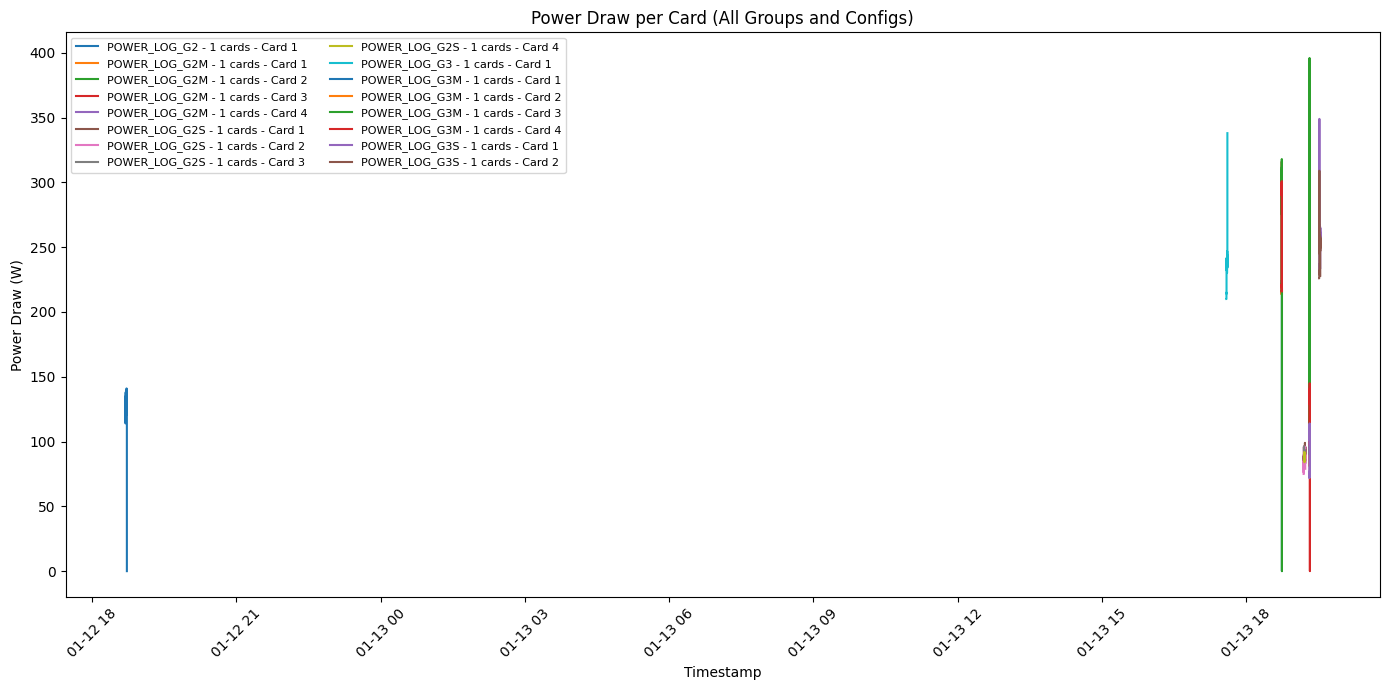

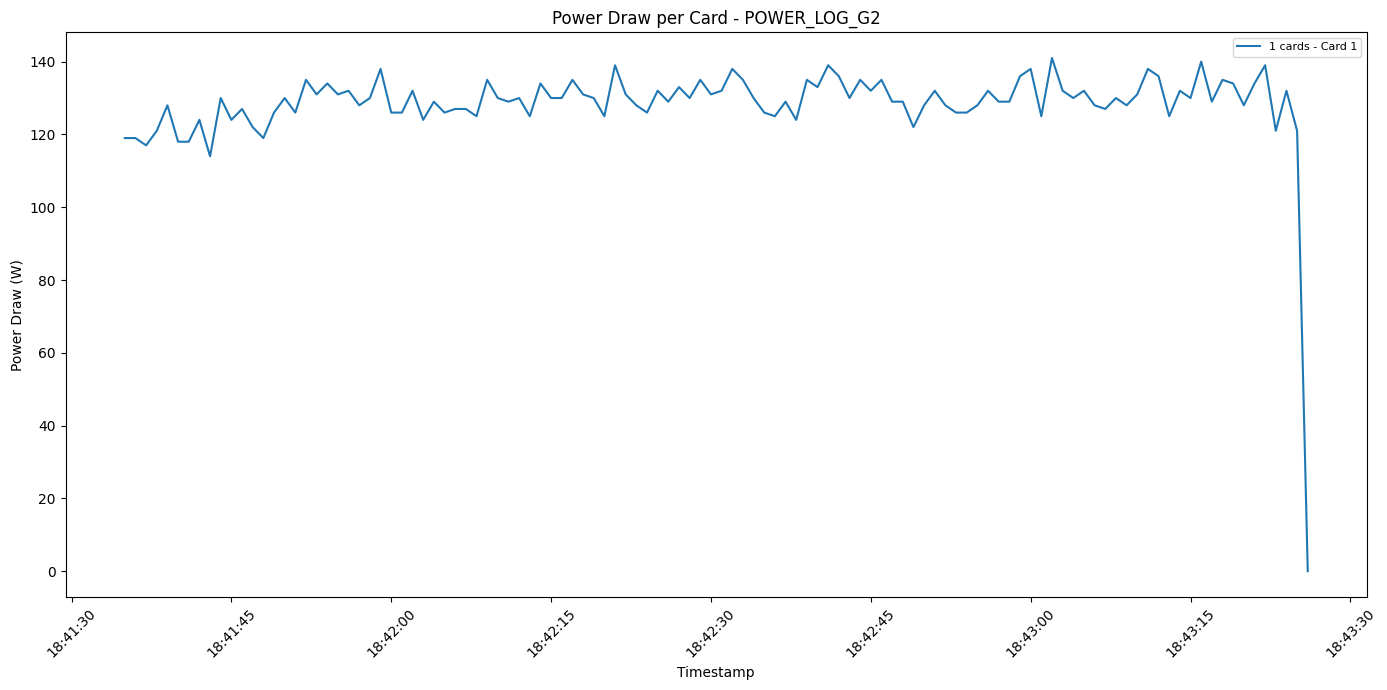

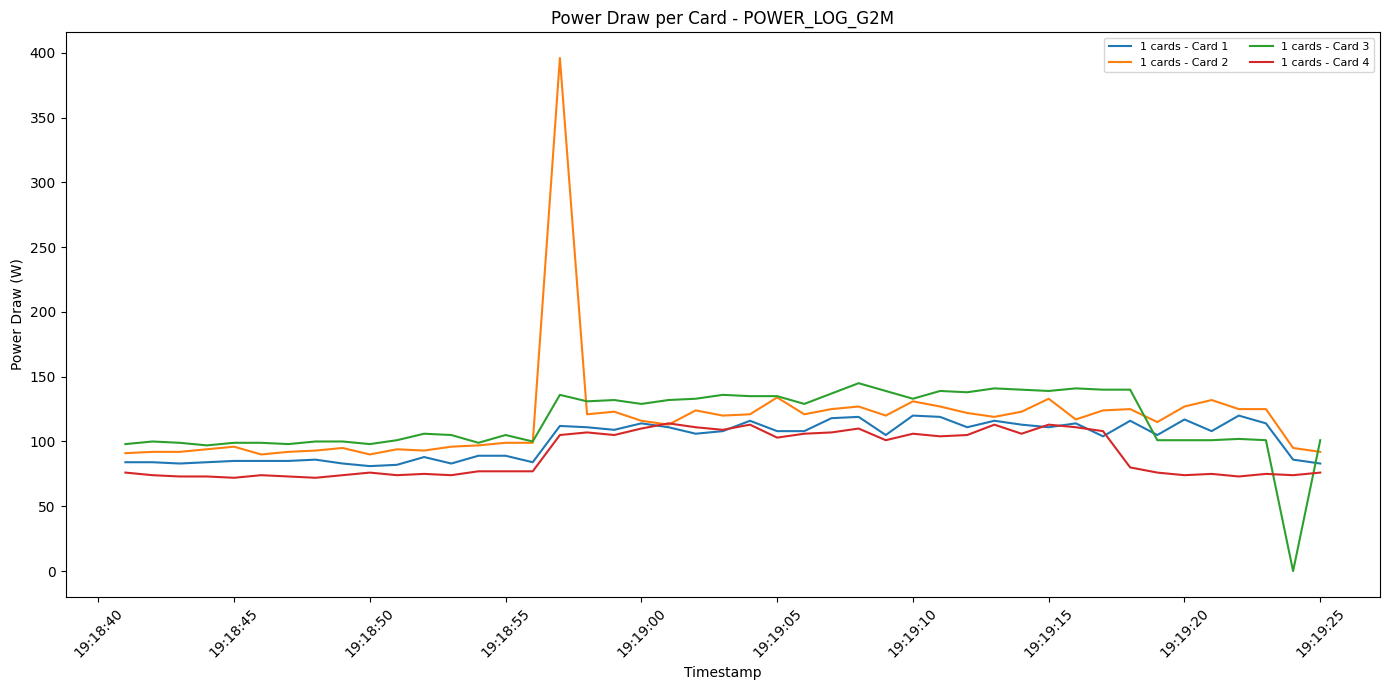

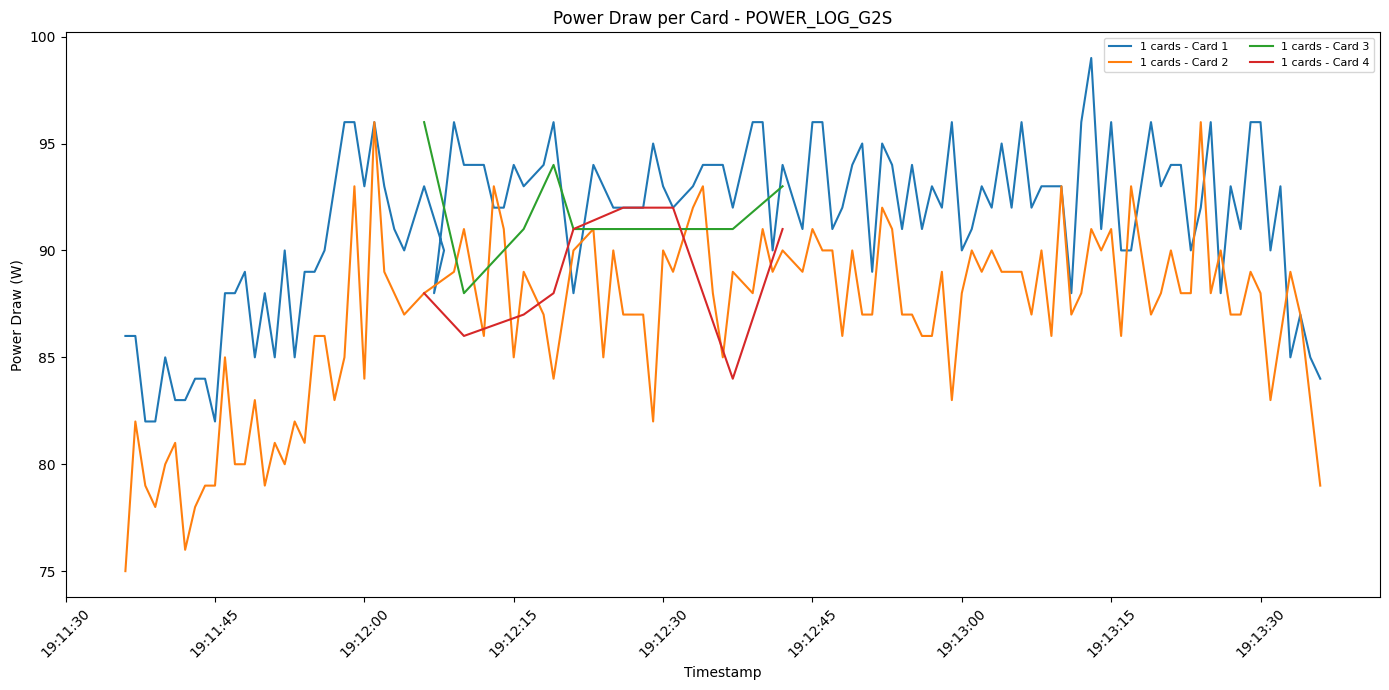

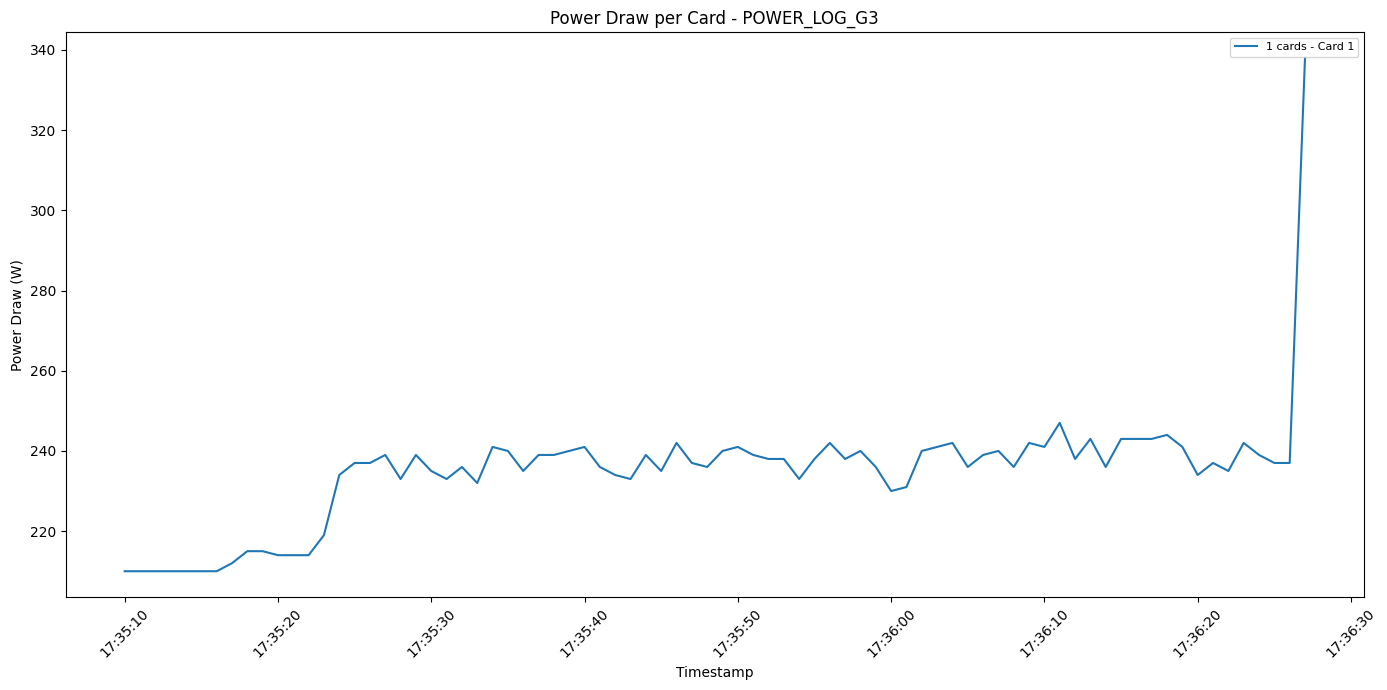

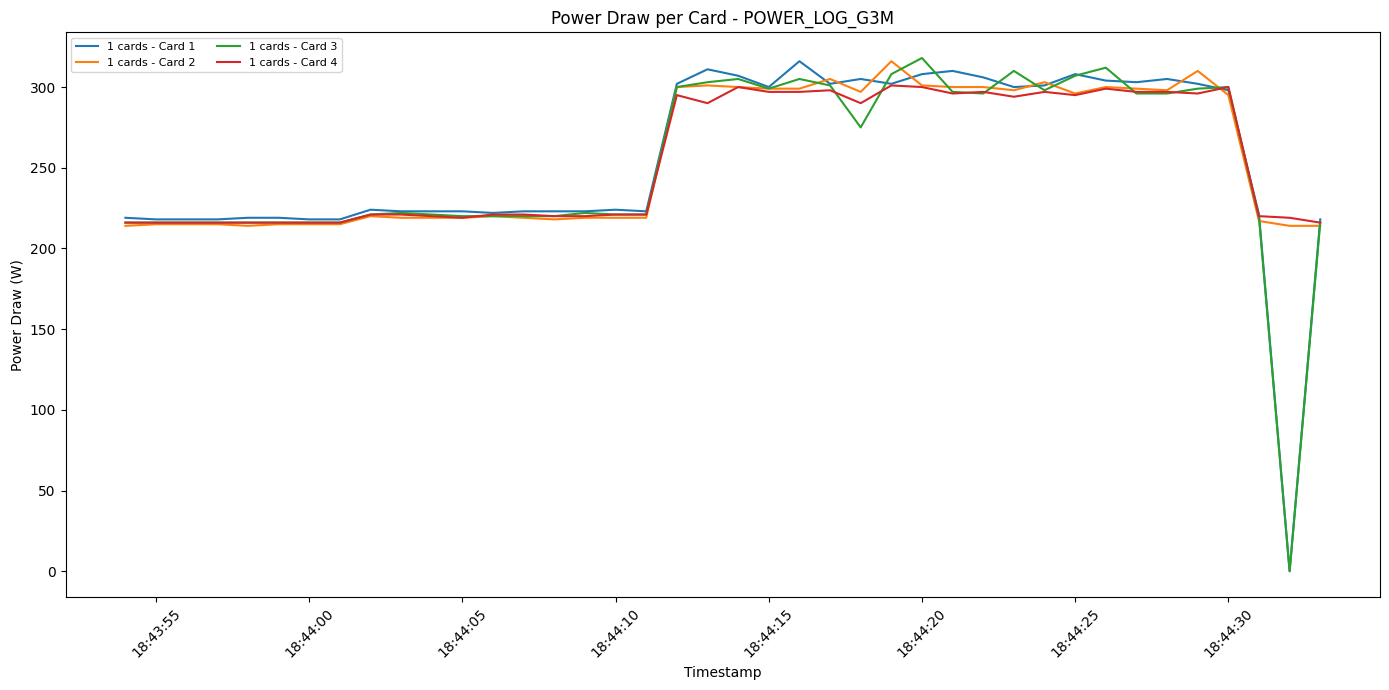

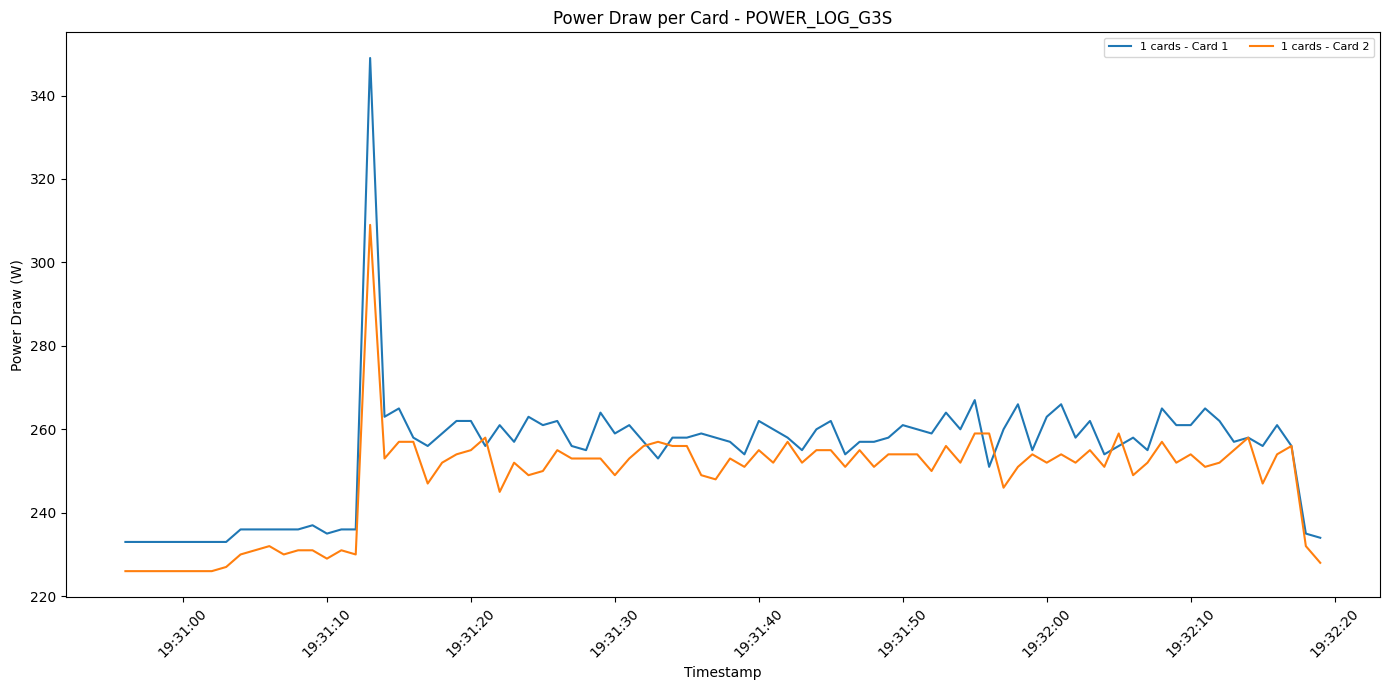

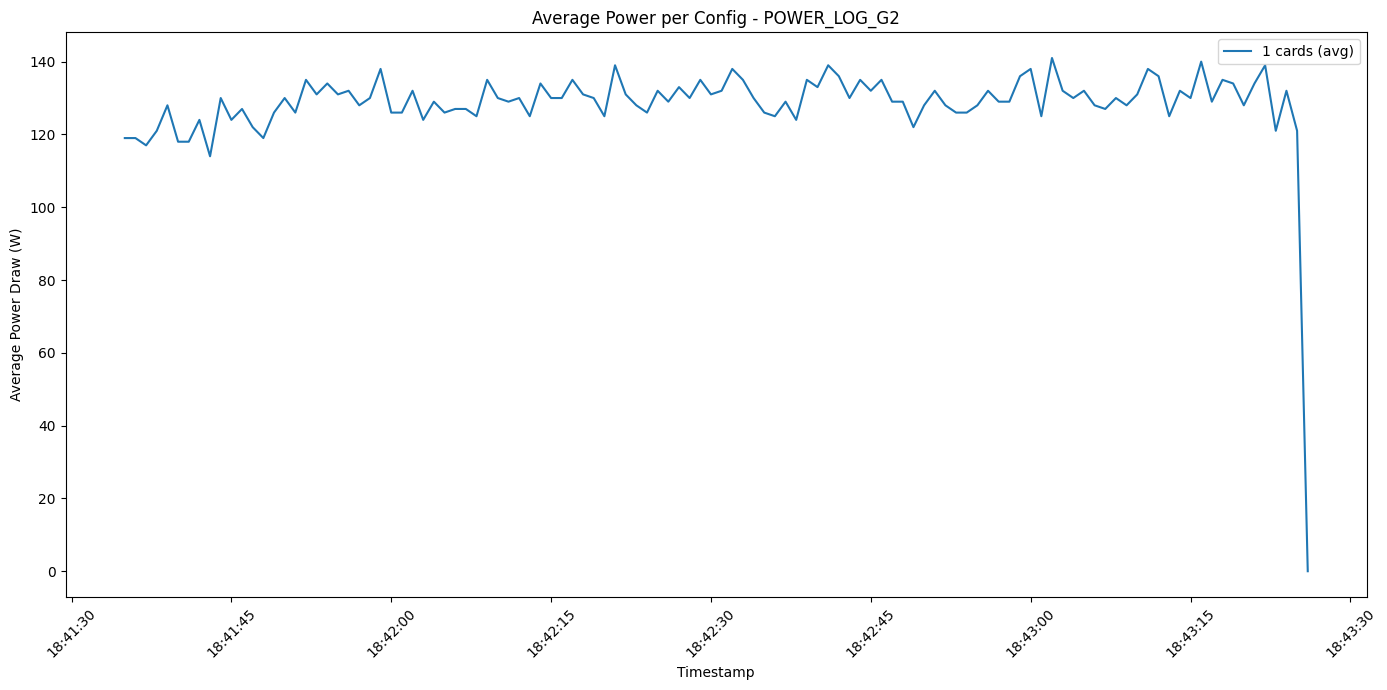

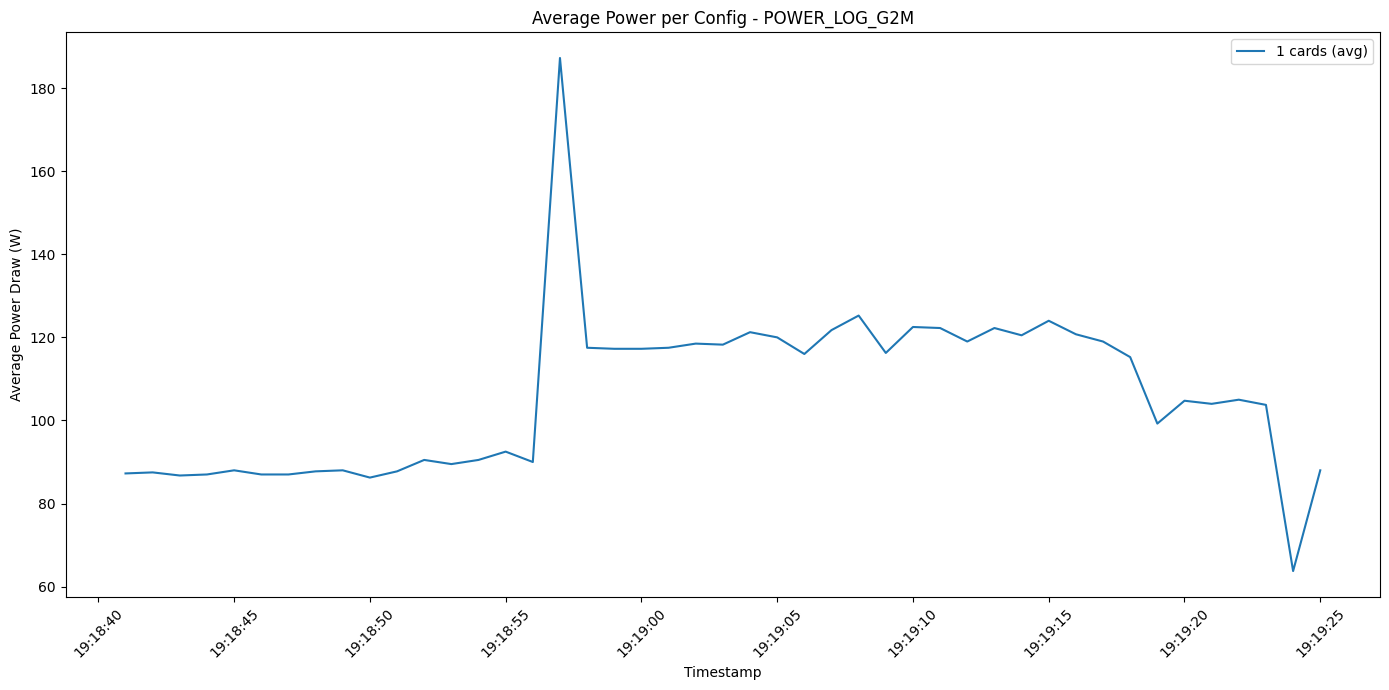

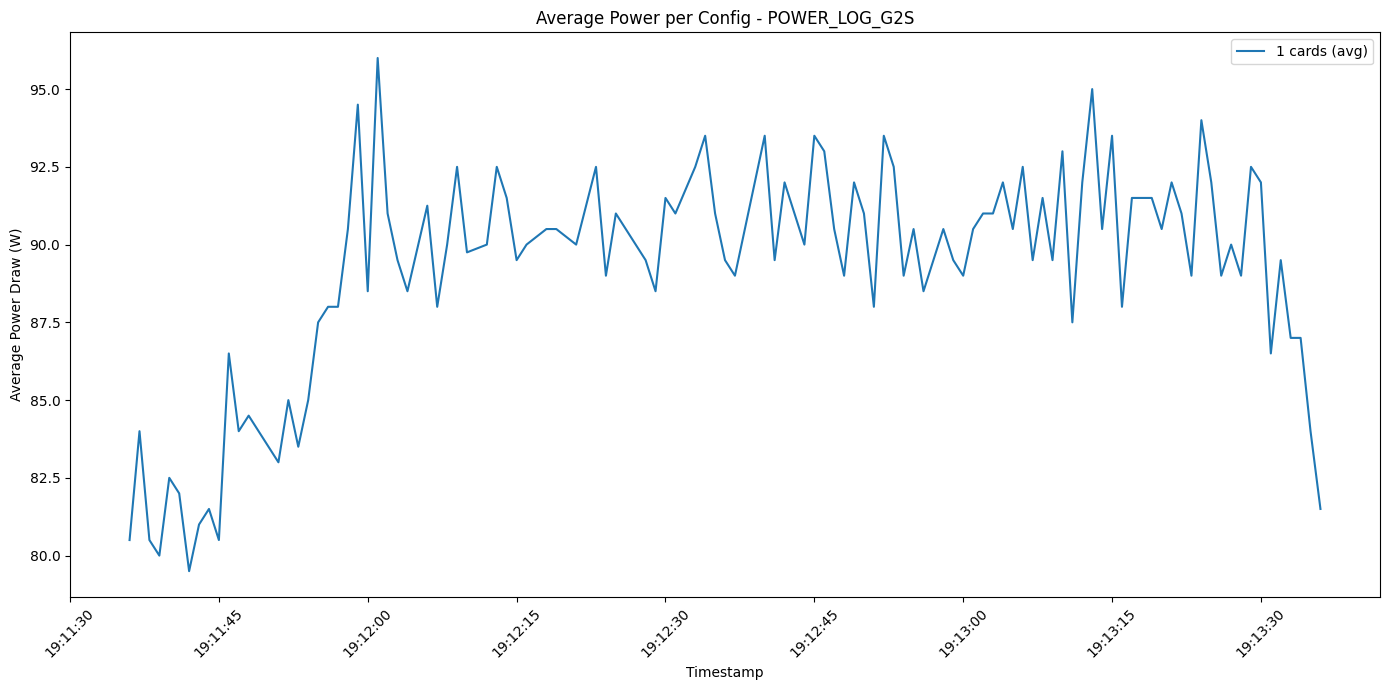

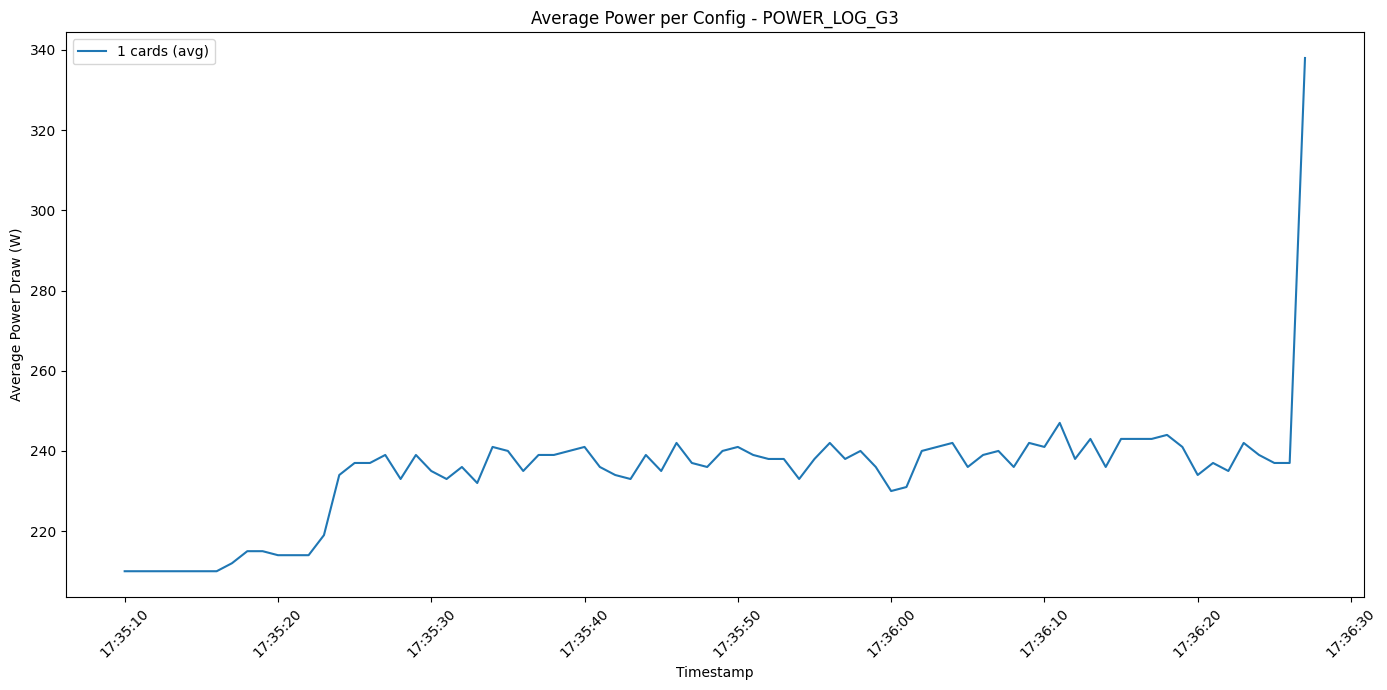

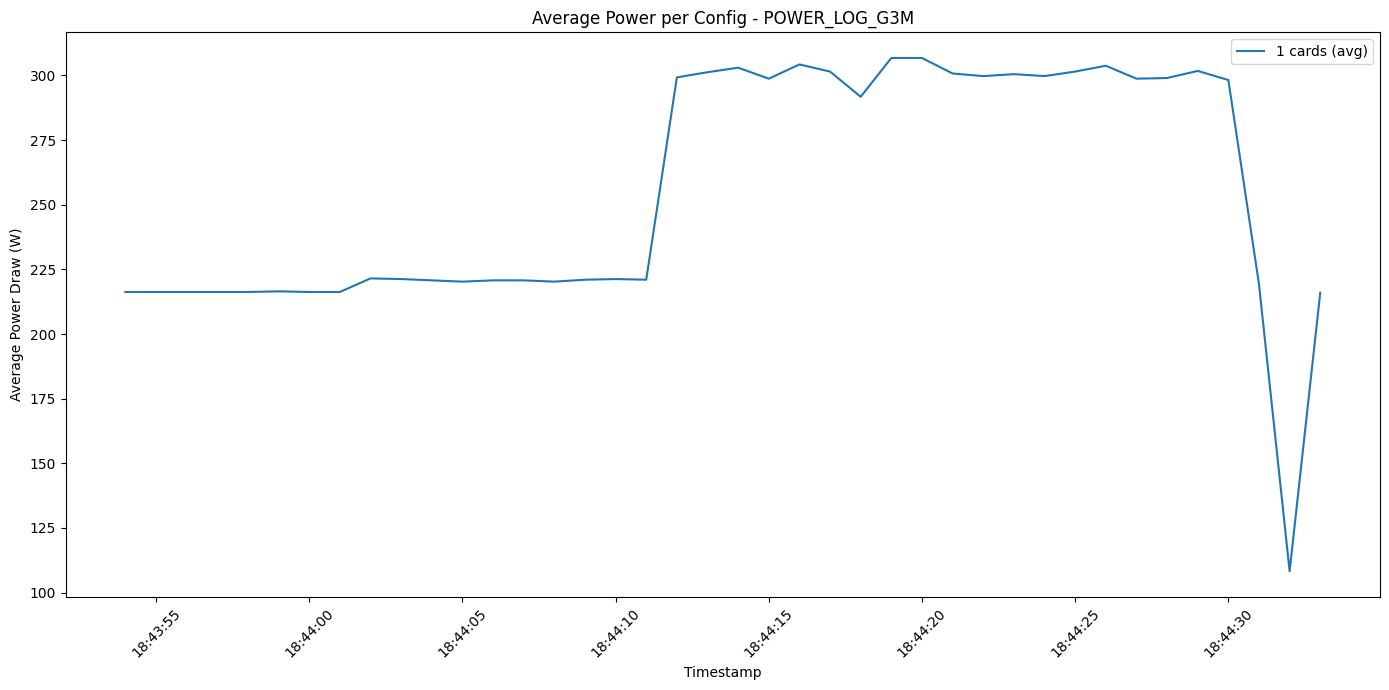

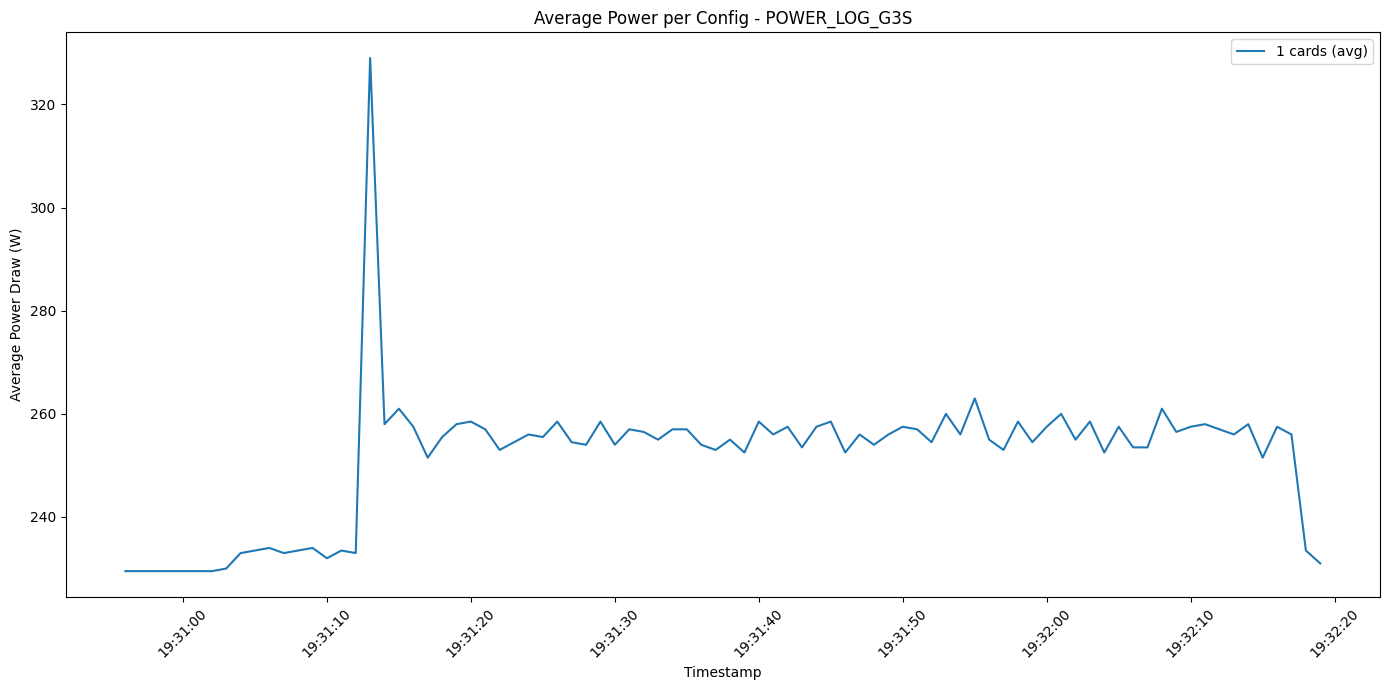

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Folder containing logs
folder = "power_logs"

def load_and_prepare(file_path):
    # Get filename without extension
    base = os.path.basename(file_path).replace(".csv", "")

    # Split into group (g2/g3) and config (s/m/l or empty for 1 card)
    parts = base.split(".")
    group = parts[0]  # g2 or g3
    config = parts[1] if len(parts) > 1 else "1"  # s=2, m=4, l=8, none=1

    mapping = {"s": "2", "m": "4", "l": "8"}
    num_cards = mapping.get(config, config)  # map to 1/2/4/8

    # Load CSV
    df = pd.read_csv(file_path)

    # Clean power column
    df[' power.draw [W]'] = (
        df[' power.draw [W]'].astype(str).str.replace(' W', '', regex=False).astype(int)
    )

    # Convert timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Assign card IDs (1..n for each second)
    df['card_id'] = df.groupby('timestamp').cumcount() + 1

    # Add metadata
    df['group'] = group
    df['num_cards'] = int(num_cards)

    return df

# Load all logs
all_files = glob.glob(os.path.join(folder, "*.csv"))
df = pd.concat([load_and_prepare(f) for f in all_files], ignore_index=True)

# --- Combined plot (all groups + configs) ---
plt.figure(figsize=(14, 7))
for (group, num_cards, card_id), data in df.groupby(['group', 'num_cards', 'card_id']):
    plt.plot(data['timestamp'], data[' power.draw [W]'],
             label=f'{group.upper()} - {num_cards} cards - Card {card_id}')

plt.xlabel("Timestamp")
plt.ylabel("Power Draw (W)")
plt.title("Power Draw per Card (All Groups and Configs)")
plt.legend(ncol=2, fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Separate plots for each group (G2, G3) ---
for group, group_data in df.groupby("group"):
    plt.figure(figsize=(14, 7))
    for (num_cards, card_id), data in group_data.groupby(['num_cards', 'card_id']):
        plt.plot(data['timestamp'], data[' power.draw [W]'],
                 label=f'{num_cards} cards - Card {card_id}')
    plt.xlabel("Timestamp")
    plt.ylabel("Power Draw (W)")
    plt.title(f"Power Draw per Card - {group.upper()}")
    plt.legend(ncol=2, fontsize=8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Average power per second per config (scaling view) ---
df_avg = df.groupby(['group', 'num_cards', 'timestamp'])[' power.draw [W]'].mean().reset_index()

for group, group_data in df_avg.groupby("group"):
    plt.figure(figsize=(14, 7))
    for num_cards, data in group_data.groupby('num_cards'):
        plt.plot(data['timestamp'], data[' power.draw [W]'],
                 label=f'{num_cards} cards (avg)')
    plt.xlabel("Timestamp")
    plt.ylabel("Average Power Draw (W)")
    plt.title(f"Average Power per Config - {group.upper()}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-2895150899.py:22: FutureWarning: Parsed string "Tue Jan 13 17:35:10 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-2895150899.py:22: FutureWarning: Parsed string "Tue Jan 13 19:30:56 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-2895150899.py:22: FutureWarning: Parsed string "Tue Jan 13 19:11:36 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; 

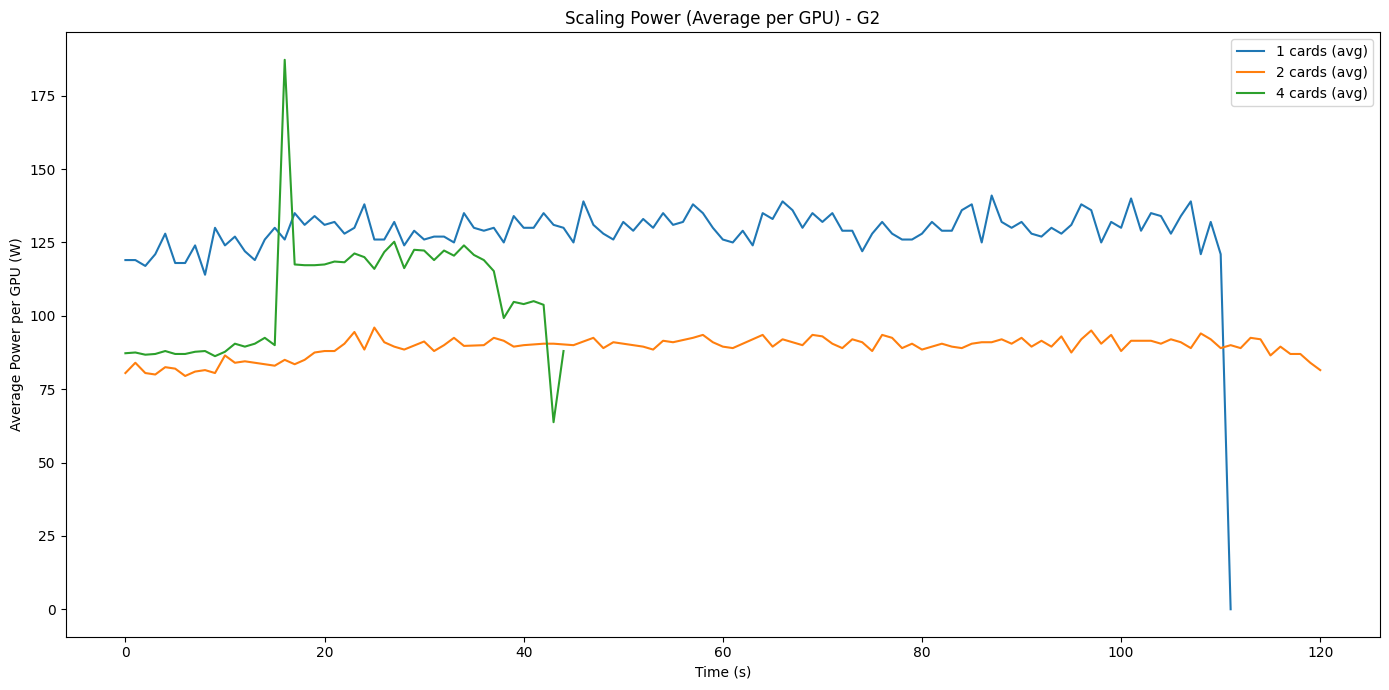

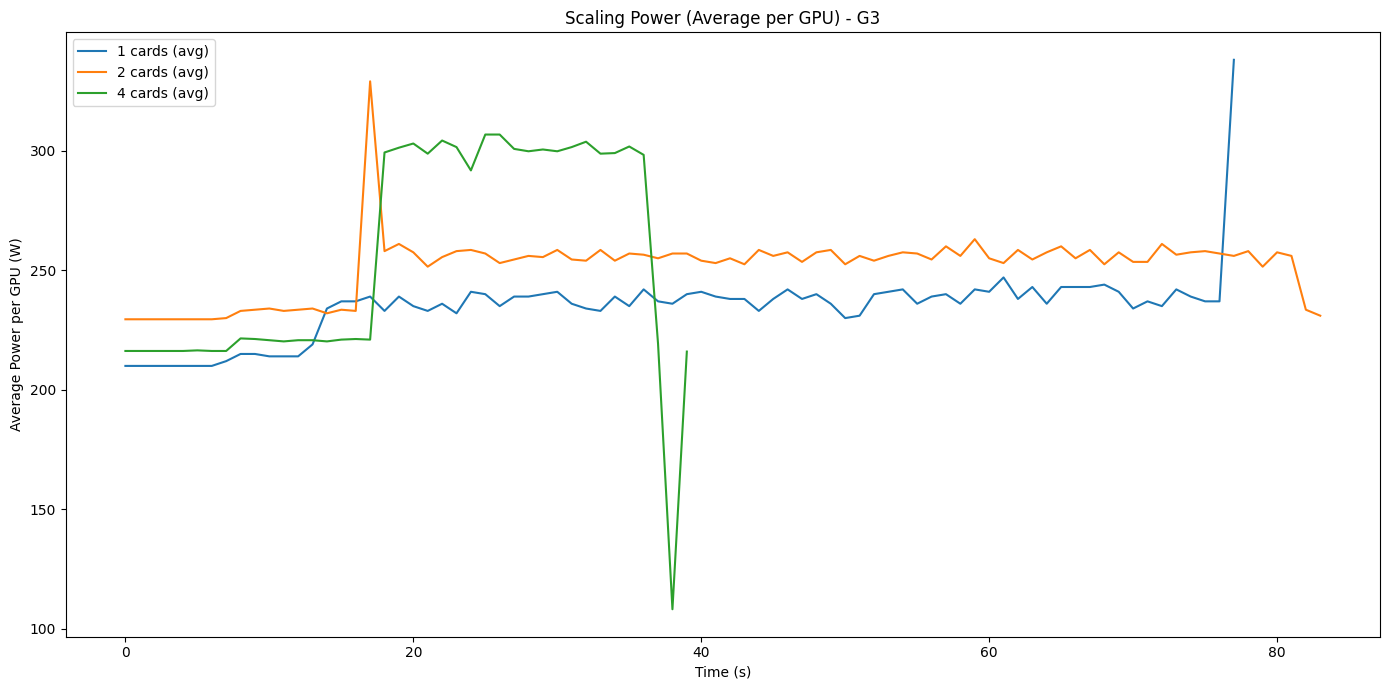

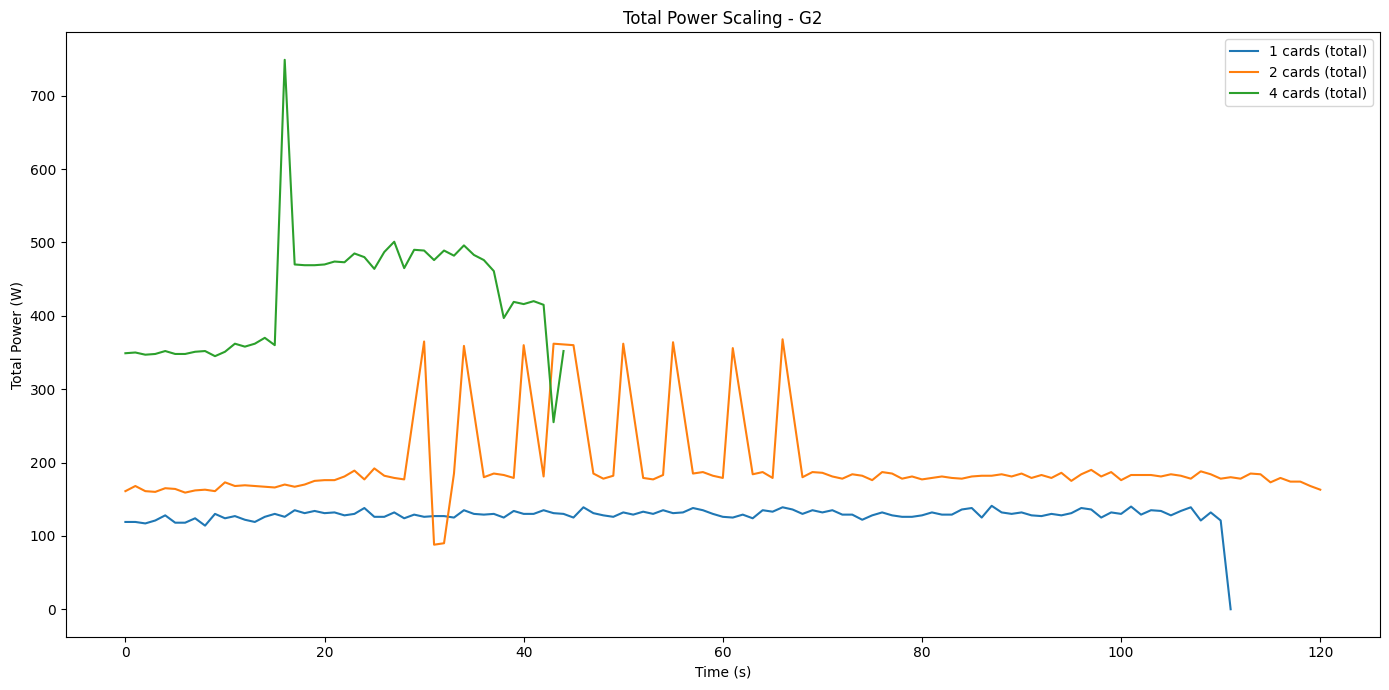

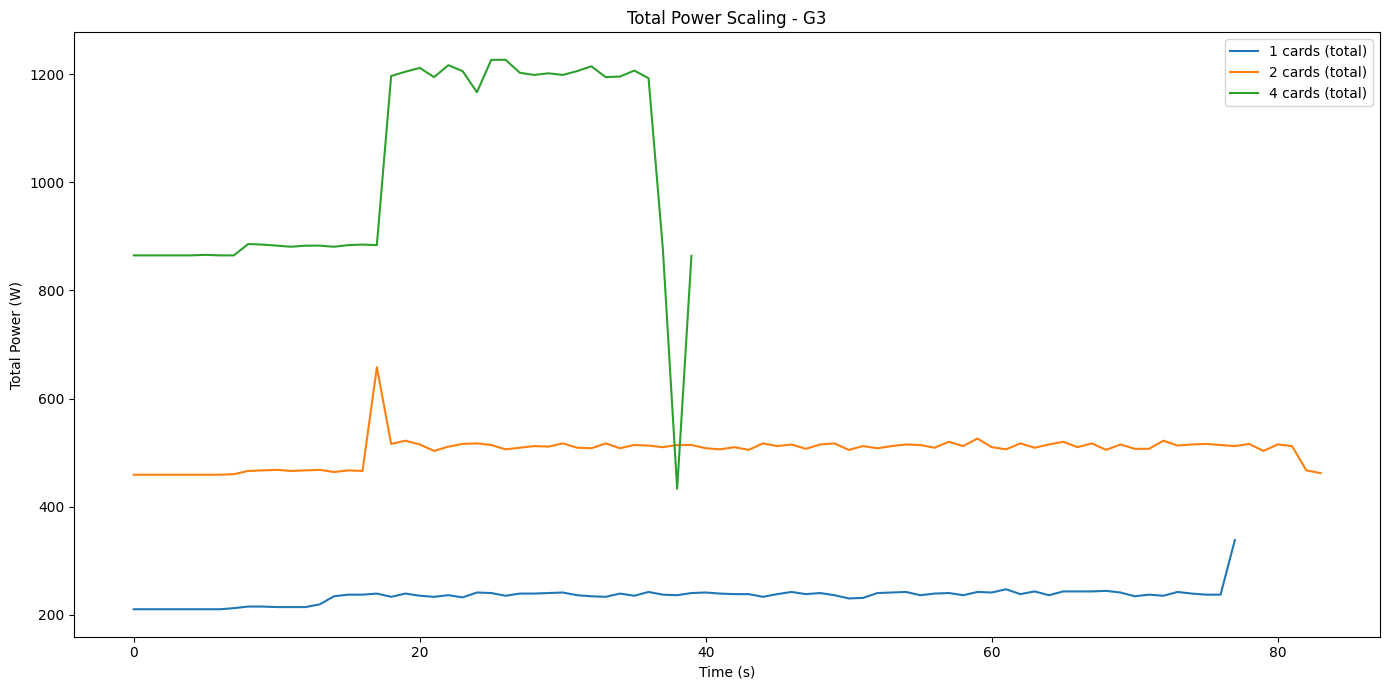

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Folder containing logs
folder = "power_logs"

def load_and_prepare(file_path):
    base = os.path.basename(file_path).replace(".csv", "")
    tag = base.split("_")[-1]  # g2, g2s, g2m, g2l, g3...

    # Identify group and config
    group = tag[:2]  # g2 or g3
    config = tag[2:] if len(tag) > 2 else ""
    mapping = {"s": 2, "m": 4, "l": 8, "": 1}
    num_cards = mapping.get(config, 1)

    # Load CSV
    df = pd.read_csv(file_path)
    df[' power.draw [W]'] = df[' power.draw [W]'].astype(str).str.replace(' W', '', regex=False).astype(int)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')


    # Relative time in seconds (start from 0)
    df['time_sec'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

    # Assign card IDs (1..n per second)
    df['card_id'] = df.groupby('time_sec').cumcount() + 1

    # Metadata
    df['group'] = group
    df['num_cards'] = num_cards
    return df

# Load all logs
all_files = glob.glob(os.path.join(folder, "*.csv"))
df = pd.concat([load_and_prepare(f) for f in all_files], ignore_index=True)

# --- Average power per GPU (scaling) ---
df_avg = df.groupby(['group', 'num_cards', 'time_sec'])[' power.draw [W]'].mean().reset_index()

for group, group_data in df_avg.groupby("group"):
    plt.figure(figsize=(14, 7))
    for num_cards, data in sorted(group_data.groupby('num_cards')):
        plt.plot(data['time_sec'], data[' power.draw [W]'], label=f'{num_cards} cards (avg)')
    plt.xlabel("Time (s)")
    plt.ylabel("Average Power per GPU (W)")
    plt.title(f"Scaling Power (Average per GPU) - {group.upper()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Total system power per config ---
df_sum = df.groupby(['group', 'num_cards', 'time_sec'])[' power.draw [W]'].sum().reset_index()

for group, group_data in df_sum.groupby("group"):
    plt.figure(figsize=(14, 7))
    for num_cards, data in sorted(group_data.groupby('num_cards')):
        plt.plot(data['time_sec'], data[' power.draw [W]'], label=f'{num_cards} cards (total)')
    plt.xlabel("Time (s)")
    plt.ylabel("Total Power (W)")
    plt.title(f"Total Power Scaling - {group.upper()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    '''
    observation in power logs comparision
    g2: we can see that the single and 2 cards take significantly more time to run and  see that for a long duration the power consumed by the single container or two container setup is high for a long time.
    g3: we can see the single and 2 card set up consume lesser power than the 4 and 8 card machine

    comparision in g2 and g3: we see significantly higher power consumption in the g3

    The most efficient
    '''

/tmp/ipython-input-3889820485.py:20: FutureWarning: Parsed string "Tue Jan 13 17:35:10 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-3889820485.py:20: FutureWarning: Parsed string "Tue Jan 13 19:30:56 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-3889820485.py:20: FutureWarning: Parsed string "Tue Jan 13 19:11:36 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; 

  Group  Cards  Energy (J)  Energy (kWh)
0    G2      1     14305.5      0.003974
1    G2      2     23787.5      0.006608
2    G2      4     18774.5      0.005215
3    G3      1     18039.0      0.005011
4    G3      2     41795.5      0.011610
5    G3      4     39933.5      0.011093


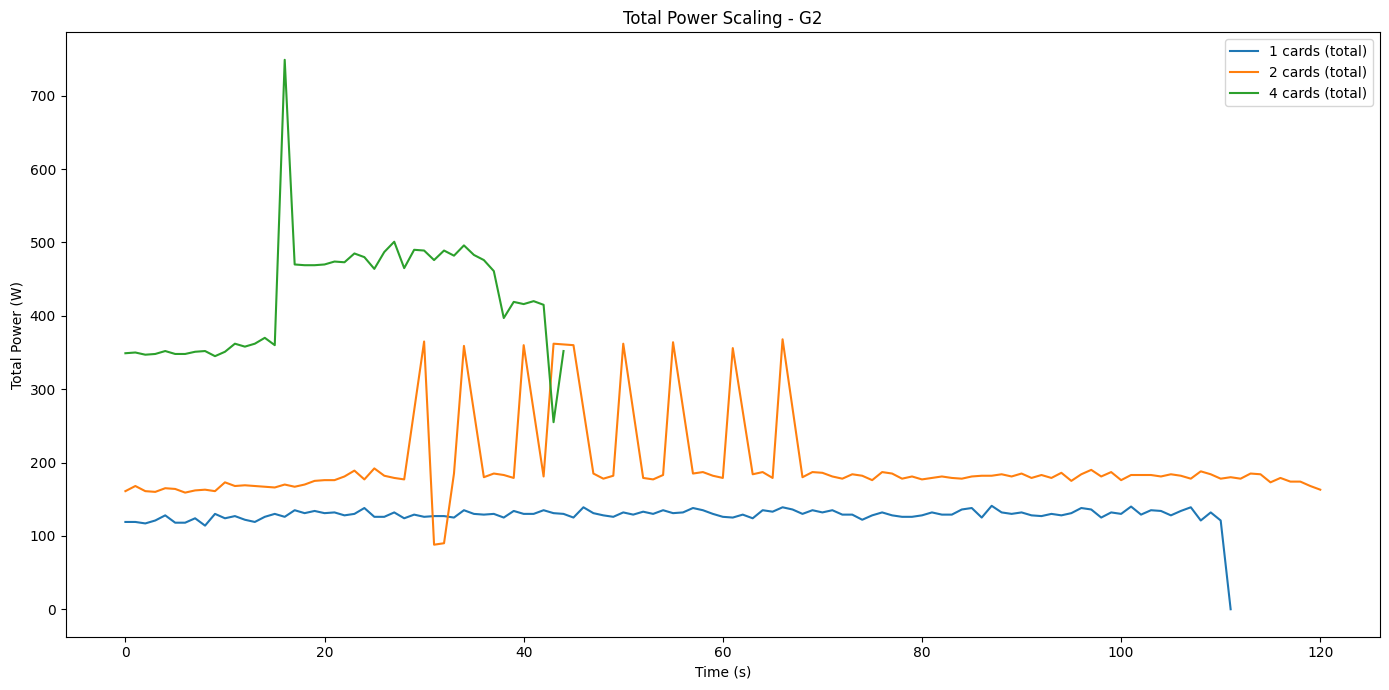

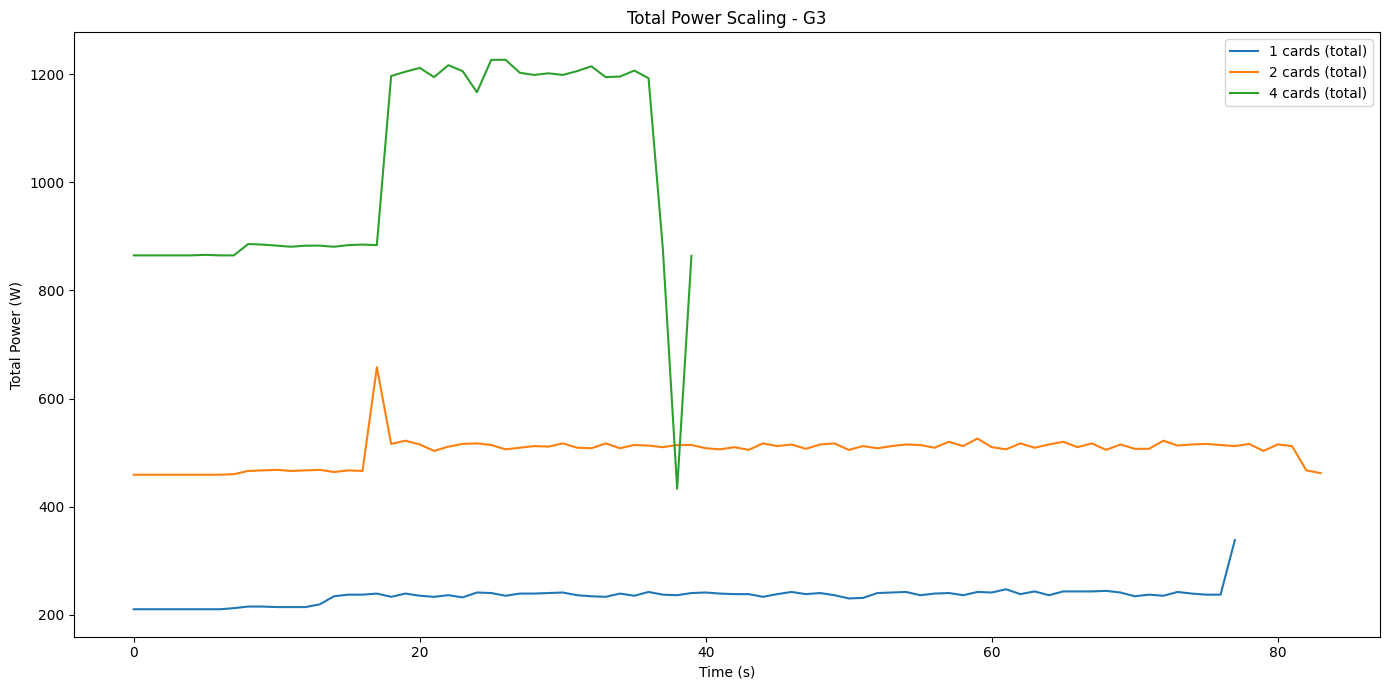

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Folder containing logs
folder = "power_logs"

def load_and_prepare(file_path):
    base = os.path.basename(file_path).replace(".csv", "")
    tag = base.split("_")[-1]  # g2, g2s, g2m, g2l, g3...

    group = tag[:2]  # g2 or g3
    config = tag[2:] if len(tag) > 2 else ""
    mapping = {"s": 2, "m": 4, "l": 8, "": 1}
    num_cards = mapping.get(config, 1)

    df = pd.read_csv(file_path)
    df[' power.draw [W]'] = df[' power.draw [W]'].astype(str).str.replace(' W', '', regex=False).astype(int)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
    df['time_sec'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
    df['card_id'] = df.groupby('time_sec').cumcount() + 1
    df['group'] = group
    df['num_cards'] = num_cards
    return df

# Load all logs
all_files = glob.glob(os.path.join(folder, "*.csv"))
df = pd.concat([load_and_prepare(f) for f in all_files], ignore_index=True)

# --- Compute total energy per run (sum of all cards) ---
df_sum = df.groupby(['group', 'num_cards', 'time_sec'])[' power.draw [W]'].sum().reset_index()

energy_results = []
for (group, num_cards), run_data in df_sum.groupby(['group', 'num_cards']):
    run_data = run_data.sort_values('time_sec')
    energy_joules = 0
    for i in range(1, len(run_data)):
        dt = run_data['time_sec'].iloc[i] - run_data['time_sec'].iloc[i-1]
        avg_power = (run_data[' power.draw [W]'].iloc[i] + run_data[' power.draw [W]'].iloc[i-1]) / 2
        energy_joules += avg_power * dt

    energy_kwh = energy_joules / 3.6e6
    energy_results.append({
        "Group": group.upper(),
        "Cards": num_cards,
        "Energy (J)": energy_joules,
        "Energy (kWh)": energy_kwh
    })

energy_df = pd.DataFrame(energy_results)
print(energy_df)

# Optional: plot total power curves for scaling
for group, group_data in df_sum.groupby("group"):
    plt.figure(figsize=(14, 7))
    for num_cards, data in sorted(group_data.groupby('num_cards')):
        plt.plot(data['time_sec'], data[' power.draw [W]'], label=f'{num_cards} cards (total)')
    plt.xlabel("Time (s)")
    plt.ylabel("Total Power (W)")
    plt.title(f"Total Power Scaling - {group.upper()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1064892133.py:20: FutureWarning: Parsed string "Tue Jan 13 17:35:10 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-1064892133.py:20: FutureWarning: Parsed string "Tue Jan 13 19:30:56 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
/tmp/ipython-input-1064892133.py:20: FutureWarning: Parsed string "Tue Jan 13 19:11:36 IST 2026" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; 

  Group  Cards  Total Time (s)  Energy (J)  Energy (kWh)
0    G2      1           111.0     14305.5      0.003974
1    G2      2           120.0     23787.5      0.006608
2    G2      4            44.0     18774.5      0.005215
3    G3      1            77.0     18039.0      0.005011
4    G3      2            83.0     41795.5      0.011610
5    G3      4            39.0     39933.5      0.011093


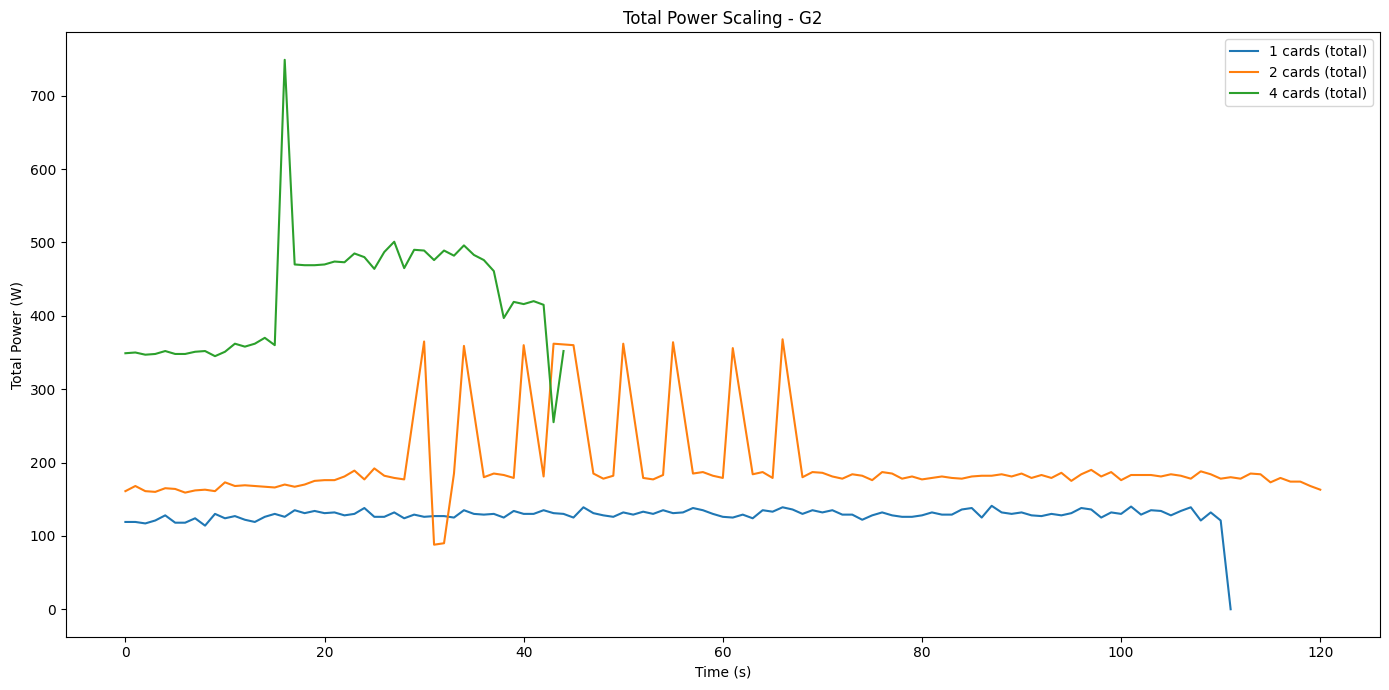

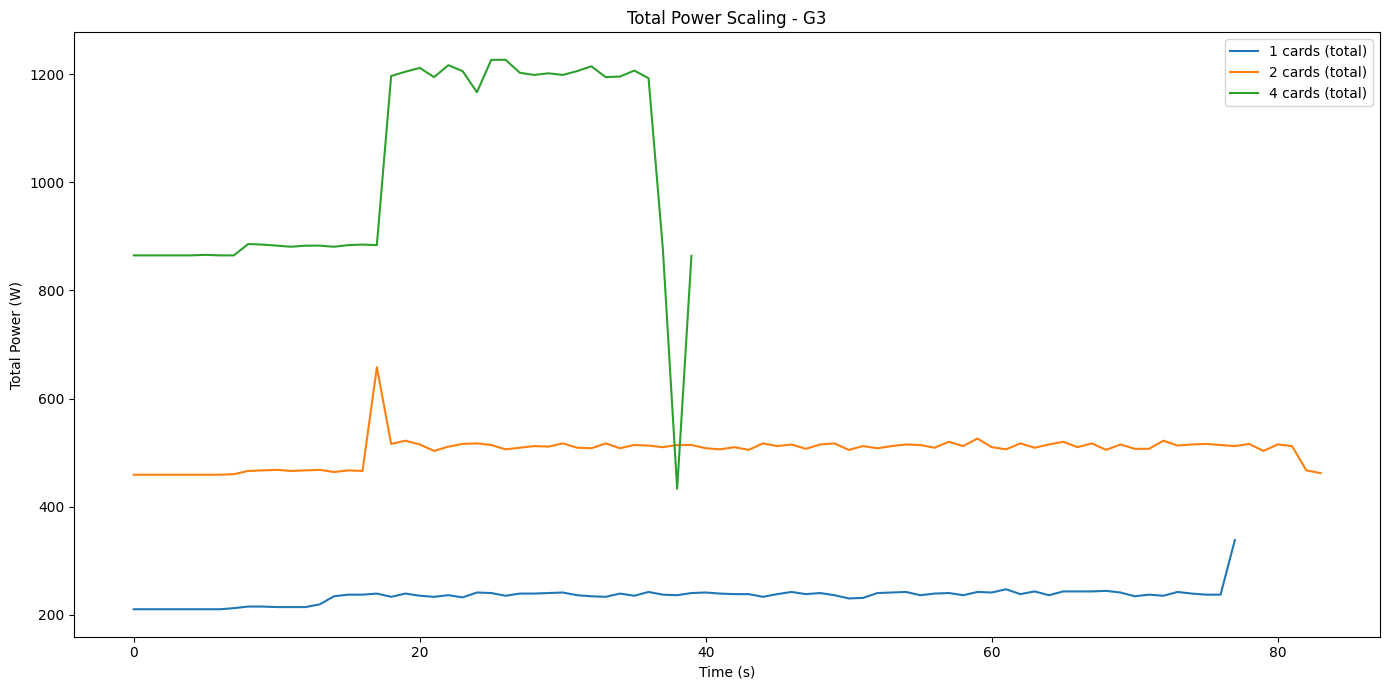

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Folder containing logs
folder = "power_logs"

def load_and_prepare(file_path):
    base = os.path.basename(file_path).replace(".csv", "")
    tag = base.split("_")[-1]  # g2, g2s, g2m, g2l, g3...

    group = tag[:2]  # g2 or g3
    config = tag[2:] if len(tag) > 2 else ""
    mapping = {"s": 2, "m": 4, "l": 8, "": 1}
    num_cards = mapping.get(config, 1)

    df = pd.read_csv(file_path)
    df[' power.draw [W]'] = df[' power.draw [W]'].astype(str).str.replace(' W', '', regex=False).astype(int)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
    df['time_sec'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
    df['card_id'] = df.groupby('time_sec').cumcount() + 1
    df['group'] = group
    df['num_cards'] = num_cards
    return df

# Load all logs
all_files = glob.glob(os.path.join(folder, "*.csv"))
df = pd.concat([load_and_prepare(f) for f in all_files], ignore_index=True)

# --- Compute total energy + inference time per run ---
df_sum = df.groupby(['group', 'num_cards', 'time_sec'])[' power.draw [W]'].sum().reset_index()

results = []
for (group, num_cards), run_data in df_sum.groupby(['group', 'num_cards']):
    run_data = run_data.sort_values('time_sec')

    # Total time taken (seconds)
    total_time = run_data['time_sec'].max() - run_data['time_sec'].min()

    # Energy integration
    energy_joules = 0
    for i in range(1, len(run_data)):
        dt = run_data['time_sec'].iloc[i] - run_data['time_sec'].iloc[i-1]
        avg_power = (run_data[' power.draw [W]'].iloc[i] + run_data[' power.draw [W]'].iloc[i-1]) / 2
        energy_joules += avg_power * dt

    energy_kwh = energy_joules / 3.6e6

    results.append({
        "Group": group.upper(),
        "Cards": num_cards,
        "Total Time (s)": total_time,
        "Energy (J)": energy_joules,
        "Energy (kWh)": energy_kwh
    })

summary_df = pd.DataFrame(results)
print(summary_df)

# --- Optional: visualize total power curves ---
for group, group_data in df_sum.groupby("group"):
    plt.figure(figsize=(14, 7))
    for num_cards, data in sorted(group_data.groupby('num_cards')):
        plt.plot(data['time_sec'], data[' power.draw [W]'], label=f'{num_cards} cards (total)')
    plt.xlabel("Time (s)")
    plt.ylabel("Total Power (W)")
    plt.title(f"Total Power Scaling - {group.upper()}")
    plt.legend()
    plt.tight_layout()
    plt.show()